In [28]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [29]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor as VIF
from statsmodels.stats.multicomp import pairwise_tukeyhsd

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [30]:
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)
#Sınırları kaldırdım

In [31]:
df = pd.read_csv("/content/drive/MyDrive/amazon.csv")

print(f"Veri seti: {df.shape[0]} satır, {df.shape[1]} sütun")

print("tekrar eden satır:", df.duplicated().sum())


df["discounted_price"] = (df["discounted_price"].str.replace("₹",' ').str.replace(",",'').str.strip()).astype(float)
df["actual_price"] = df["actual_price"].str.replace("₹",' ').str.replace(",",'').str.strip().astype(float)
df["discount_percentage"] = df["discount_percentage"].str.replace("%",' ').str.strip().astype(float)
df["rating_count"] = (df["rating_count"].str.replace(",",'').str.strip()).dropna().astype(int)
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')
df = df.dropna(subset=['rating'])



df.head()


Veri seti: 1465 satır, 16 sütun
tekrar eden satır: 0


,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,399.0,1099.0,64.0,4.2,24269.0,High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,199.0,349.0,43.0,4.0,43994.0,"Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,199.0,1899.0,90.0,3.9,7928.0,【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,329.0,699.0,53.0,4.2,94363.0,The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,154.0,399.0,61.0,4.2,16905.0,[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...


##  Genel Bakış Özet

In [32]:
ozet = pd.DataFrame({
    "dtype": df.dtypes,
    "n_unique": df.nunique(),
    "eksik_değer":df.isnull().sum(),
    "eksik_değer_yüzdesi":(df.isnull().mean()*100).round(2)
})

ozet

,dtype,n_unique,eksik_değer,eksik_değer_yüzdesi
product_id,object,1350,0,0.00
product_name,object,1336,0,0.00
category,object,211,0,0.00
discounted_price,float64,550,0,0.00
actual_price,float64,449,0,0.00
discount_percentage,float64,92,0,0.00
rating,float64,25,0,0.00
rating_count,float64,1142,2,0.14
about_product,object,1292,0,0.00
user_id,object,1193,0,0.00


# **Betimsel İstatistik ve güven aralığı**

In [33]:
def ortalama_guven_araligi(seri, guven=0.95):
  veri = seri.dropna()
  n = len(veri)
  ortalama = veri.mean()
  sem = stats.sem(veri) # standart error of the mean

  t_kritik = stats.t.ppf((1+guven)/2 ,df =n-1)
  hata_payi = t_kritik*sem

  return ortalama,ortalama-hata_payi,ortalama+hata_payi

sayisal_sutunlar = ["discounted_price", "actual_price", "discount_percentage", "rating", "rating_count"]
kategorik_sutunlar = ["product_id","product_name", "category", "about_product","user_id", "user_name",
                  	"review_id", "review_title", "review_content", "img_link", "product_link"]

print(f"{'değişken':20s},{'Ortalama':>12s},{'%95 Alt':>12s},{'%95 Üst':>12s}")
for degisken in sayisal_sutunlar:
  ortalama,alt,ust = ortalama_guven_araligi(df[degisken])
  print(f"{degisken:20s},{ortalama:>12.2f},{alt:>12.2f},{ust:>12.2f}")

değişken            ,    Ortalama,     %95 Alt,     %95 Üst
discounted_price    ,     3126.01,     2769.88,     3482.14
actual_price        ,     5447.00,     4889.31,     6004.70
discount_percentage ,       47.71,       46.60,       48.82
rating              ,        4.10,        4.08,        4.11
rating_count        ,    18307.38,    16113.39,    20501.36


##**Yorumlar**:
- İndirimli ve gerçek fiyatlar, değerlendirme sayılarında homojenlikten değerlendirme puanı ve indirim yüzdesine kıyasla daha az söz edilebilir.

In [34]:
betimsel = df[sayisal_sutunlar].describe().T
betimsel["skew"] = df[sayisal_sutunlar].skew()
betimsel["kurtosis"] = df[sayisal_sutunlar].kurtosis()
betimsel.round(2)

,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
discounted_price,1464.0,3126.01,6946.63,39.0,323.75,799.0,1999.00,77990.0,4.45,25.62
actual_price,1464.0,5447.00,10878.27,39.0,800.00,1650.0,4303.75,139900.0,4.56,29.70
discount_percentage,1464.0,47.71,21.63,0.0,32.00,50.0,63.00,94.0,-0.29,-0.58
rating,1464.0,4.10,0.29,2.0,4.00,4.1,4.30,5.0,-1.24,4.36
rating_count,1462.0,18307.38,42766.10,2.0,1191.50,5179.0,17342.25,426973.0,5.67,40.33


##**Yorumlar**
***1-Skewness (Çarpıklık) Analizi:***
- Uç değerler ortalamayı rating ve discount_percentage değerlerinde ortalamadan küçüktür, discounted_price, actual_price ve rating_count'da ise ortalamadan büyüktür.

***2-Kurtosis (Basıklık) Analizi:***
- Sırasıyla rating_count, actual_price, discounted_price ve rating verileri ortalama değerin etrafında daha çok kümelenmiştir ve aşırı olayların varlığı daha olasıdır. Tepeleri sivridir.

- discount_price verileri ortalama değerin etrafında daha az kümelenmiştir ve aşırı olaylar enderdir. Tepesi daha ovaldir.

# **Normallik Testleri**

In [35]:
print(f"{'Değişken':20s} {'Shapiro-Wilk p':>16s} {'DAgostino p':>16s} {'Yorum':>16s} ")

for col in sayisal_sutunlar:
  veri= df[col].dropna()
  # shapiro n> 5000 den fazla olursa güvenilmez olur
  ornek = veri.sample(min(len(veri),5000),random_state=0)
  sw_stat, sw_p = stats.shapiro(ornek)
  da_stat, da_p = stats.normaltest(veri)
  yorum = "Normal dağılım varsayımı sağlanmaktadır." if sw_p > 0.05 else "           Normal dağılım varsayımı sağlanmamaktadır."
  print(f"{col:20s} {sw_p:>16.4f} {da_p:>16.4f} {yorum}")

Değişken               Shapiro-Wilk p      DAgostino p            Yorum 
discounted_price               0.0000           0.0000            Normal dağılım varsayımı sağlanmamaktadır.
actual_price                   0.0000           0.0000            Normal dağılım varsayımı sağlanmamaktadır.
discount_percentage            0.0000           0.0000            Normal dağılım varsayımı sağlanmamaktadır.
rating                         0.0000           0.0000            Normal dağılım varsayımı sağlanmamaktadır.
rating_count                   0.0000           0.0000            Normal dağılım varsayımı sağlanmamaktadır.


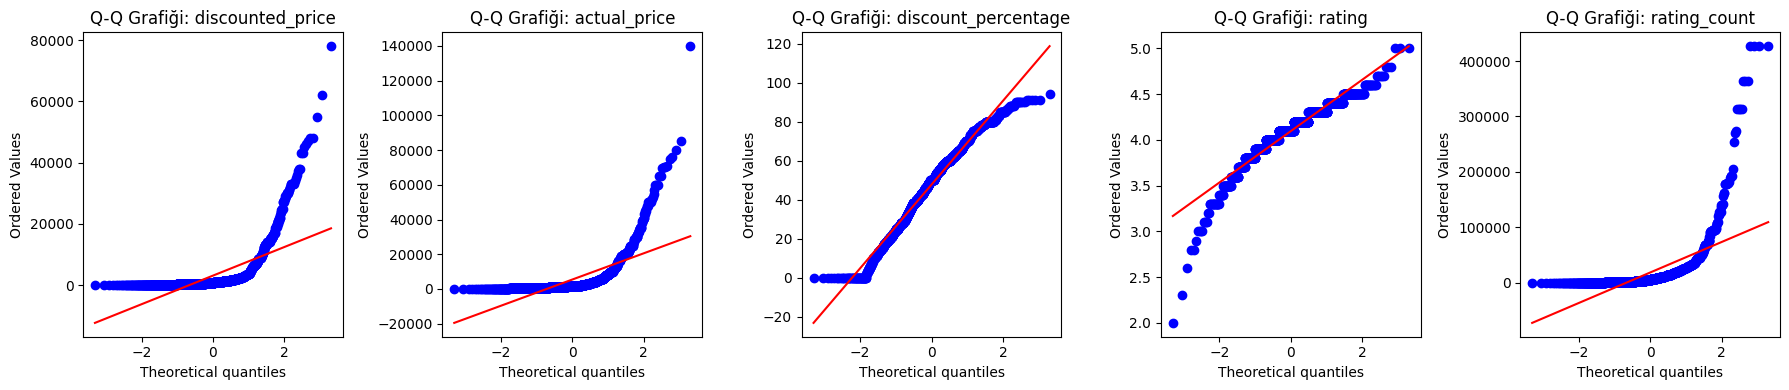

In [36]:
fig, axes = plt.subplots(1, len(sayisal_sutunlar), figsize=(18, 4))
for ax, col in zip(axes, sayisal_sutunlar):
    stats.probplot(df[col].dropna(), dist="norm", plot=ax)
    ax.set_title(f"Q-Q Grafiği: {col}")
plt.tight_layout()
plt.show()

## **Yorumlar**
- Değişkenlerin hiçbiri normal dağılım göstermediği için karşılaştırma için parametrik testleri uygulayamayacağız
- Kırmızı çizgiler ile mavi noktalar çakışsa idi normallikten söz edebilirdik, bu durumda p değerleri de 0.05 değerinden büyük olurlardı.

# **İki Grup Karşılaştırması**

In [37]:
grup0 = df.loc[df["category"].str.contains('Computers&Accessories', na=False), "discount_percentage"].dropna()
grup1 = df.loc[df["category"].str.contains('Home&Kitchen', na=False), "discount_percentage"].dropna()

levene_stat, levene_p = stats.levene(grup0, grup1)
print("Varsayımlar homojendir." if levene_p > 0.05 else "Varsayımlar homojen değildir.")
__, p0=stats.shapiro(grup0.sample(min(len(grup0),5000),random_state=0))
__, p1=stats.shapiro(grup1.sample(min(len(grup1),5000),random_state=0))
normal_mi = (p0>0.05) and (p1>0.05)
print(f"grup normallik p değerleri: Bilgisayar&Aksesurarları -> {p0:.4f}\nEv&Mutfak ürünleri -> {p1:.4f}")

Varsayımlar homojendir.
grup normallik p değerleri: Bilgisayar&Aksesurarları -> 0.0000
Ev&Mutfak ürünleri -> 0.0001


#**Yorumlar**
- İki kategorideki veriler de normal dağılıma uymuyor çarpık ya da basık özellik gösteriyorlar.
- İkisi de grupların varyans özelliği benzerlik gösterdiği için varsayımımız homojendir

# **Çoklu grup karşılaştırması**

In [38]:
df['base_category'] = df['category'].str.split('|').str[0]

In [39]:
gruplar= [g['rating'].dropna().values for _,g in df.groupby("base_category")]

f_stat, anova_p = stats.f_oneway(*gruplar)
h_stat, kw_p= stats.kruskal(*gruplar)

print(f" tek yönlü anova: f={f_stat:.3f},p={anova_p:.4f}")
print(f"kruskal-wallis: h={h_stat:.3f},p={kw_p:.4f}")

 tek yönlü anova: f=7.178,p=0.0000
kruskal-wallis: h=66.629,p=0.0000


In [40]:
N = len(df["rating"].dropna())  # Toplam veri sayısı
k = len(gruplar)  # Grup / Kategori sayısı

eta_kare = (h_stat - k + 1) / (N - k)
print(
    f"Eta Kare (Eta-Squared): {eta_kare:.4f} (0.01 küçük, 0.06 orta, 0.14 büyük"
    " etki)"
)

Eta Kare (Eta-Squared): 0.0403 (0.01 küçük, 0.06 orta, 0.14 büyük etki)


In [41]:
#post-hoc
tukey = pairwise_tukeyhsd(
    endog=df["rating"].dropna(),
    groups=df.loc[df["rating"].notna(),"base_category"],
    alpha=0.05
)

print(tukey)

               Multiple Comparison of Means - Tukey HSD, FWER=0.05                
        group1                group2        meandiff p-adj   lower   upper  reject
----------------------------------------------------------------------------------
        Car&Motorbike Computers&Accessories    0.355 0.9485 -0.5372  1.2471  False
        Car&Motorbike           Electronics   0.2817 0.9876 -0.6102  1.1737  False
        Car&Motorbike   Health&PersonalCare      0.2 0.9999 -1.0603  1.4603  False
        Car&Motorbike          Home&Kitchen   0.2407 0.9957 -0.6514  1.1329  False
        Car&Motorbike       HomeImprovement     0.45  0.937 -0.6414  1.5414  False
        Car&Motorbike    MusicalInstruments      0.1    1.0 -0.9914  1.1914  False
        Car&Motorbike        OfficeProducts   0.5097  0.716 -0.3957  1.4151  False
        Car&Motorbike            Toys&Games      0.5 0.9493 -0.7603  1.7603  False
Computers&Accessories           Electronics  -0.0732 0.0023 -0.1303 -0.0161   True
Comp

#**Yorum**
- Değişkenlerimiz normallik testini geçemediği için parametrik olmayan "Kruskal-Wallis" testini kullanacağız.
- p < 0.05 olduğu için tüm temel kategorilerin rating değerinin aynı olmadığını görüyoruz.
- h değeri oldukça yüksek olduğu için temel kategorilerin rating değerleri arasında belirgin farklar olduğuna ulaşıyoruz. Ancak Eta-Square değerinin 0.04~ olması temel kategorilerin, bu belirgin farklar üzerinde etkisinin sınırlı kaldığını gösteriyor.

##**Post-Hoc Yorumu**
*p-adj < 0.05 olan değerler anlamlı fark olduğuna işarettir.
- Computers&Accessories temel kategorisinin Electronics'e göre ortalaması anlamlı olarak düşüktür.
- Computers&Accessories temel kategorisinin Home&Kitchen'a göre ortalaması anlamlı olarak düşüktür.
- OfficeProducts temel kategorisinin Electronics'e göre ortalaması anlamlı olarak düşüktür.
- OfficeProducts temel kategorisinin Home&Kitchen'a göre ortalaması anlamlı olarak düşüktür.

- Computers&Accessories ve OfficeProducts temel kategorilerinin Home&Kitchen ve Electronics'e göre anlamlı istatistiksel farka sahip olduğunu görüyoruz. Diğer kategpriler arasında ise anlamlı istatistiksel farklar bulunamamıştır.

# **Kategorik Değişkenler Arasındaki İlişki**

In [42]:
def cramers_v(x,y):
  tablo =pd.crosstab(x,y)
  chi2 = stats.chi2_contingency(tablo)[0]
  n =tablo.sum().sum()
  k= min(tablo.shape)-1
  return np.sqrt(chi2/(n*k))

capraz = pd.crosstab(df["base_category"],df["rating"])
chi2,p,dof,beklenen =stats.chi2_contingency(capraz)
v= cramers_v(df["base_category"],df["rating"])
print(f"chi2={chi2:.4f},p={p:.4f},v={v:.4f}")
print(f"Cramer's V: {v:.4f}")
print("\n Çapraz Tablo")
print((capraz))

chi2=190.6875,p=0.5132,v=0.1276
Cramer's V: 0.1276

 Çapraz Tablo
rating                 2.0  2.3  2.6  2.8  2.9  3.0  3.1  3.2  3.3  3.4  3.5  3.6  3.7  3.8  3.9  4.0  4.1  4.2  4.3  4.4  4.5  4.6  4.7  4.8  5.0
base_category                                                                                                                                     
Car&Motorbike            0    0    0    0    0    0    0    0    0    0    0    0    0    1    0    0    0    0    0    0    0    0    0    0    0
Computers&Accessories    0    0    0    0    0    1    0    0    4    3    9    7    6   12   33   62   62   72   91   48   35    5    0    0    3
Electronics              0    0    0    1    0    2    0    1    7    3   10   11   20   36   42   64   94   89   84   38   17    5    2    0    0
Health&PersonalCare      0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    1    0    0    0    0    0    0    0    0    0
Home&Kitchen             1    1    1    1    1    1 

#**Yorum**
- p = 0.5132 yani p > 0.05 olduğu için rating ile base_category'ler arasında özel bir bağ kurmak mümkün değildir. Örneğin Electronics ürünleri her zaman OfficeProducts'dan daha yüksek rating alacaktı diyemeyiz.
- Cramer's V değerinin de sıfıra bu denli yakın olması bir önceki maddemizi kanıtlar nitelikte.
- Çapraz tablolara baktığımızda ise Home&Kitchen, Electronics ve Computers&Accessories temel kategorilerinin rating'lerinin [3.5, 4.5] aralığında yoğunlaştığını, bunun yanında Toys&Games ve Car&Motorbike temel kategorilerinde çok az ürün bulunduğunu görüyoruz.

# **Korelasyon Analizi**

In [46]:
def korelasyon_p_matrisi(veri, yontem="pearson"):
    sutunlar = veri.columns
    kat = pd.DataFrame(
        np.ones((len(sutunlar), len(sutunlar))),
        index=sutunlar,
        columns=sutunlar,
    )
    pval = pd.DataFrame(
        np.zeros((len(sutunlar), len(sutunlar))),
        index=sutunlar,
        columns=sutunlar,
    )

    for i in range(len(sutunlar)):
        for j in range(len(sutunlar)):
            if i == j:
                kat.iloc[i, j] = 1.0
                pval.iloc[i, j] = 0.0
            elif i < j:  # Simetrik olduğu için sadece üst üçgeni hesaplayıp alt üçgene kopyalıyoruz
                col1 = veri[sutunlar[i]].dropna()
                col2 = veri[sutunlar[j]].dropna()

                # İki sütundaki ortak kayıp olmayan (non-NA) indeksleri bulma
                ortak_indeks = col1.index.intersection(col2.index)

                if len(ortak_indeks) > 1:
                    x = col1.loc[ortak_indeks]
                    y = col2.loc[ortak_indeks]

                    if yontem == "pearson":
                        r, p = stats.pearsonr(x, y)
                    elif yontem == "spearman":
                        r, p = stats.spearmanr(x, y)
                    elif yontem == "kendall":
                        r, p = stats.kendalltau(x, y)
                    else:
                        raise ValueError(
                            "yontem 'pearson', 'spearman' veya 'kendall'"
                            " olmalıdır."
                        )

                    kat.iloc[i, j] = kat.iloc[j, i] = r
                    pval.iloc[i, j] = pval.iloc[j, i] = p
                else:
                    kat.iloc[i, j] = kat.iloc[j, i] = np.nan
                    pval.iloc[i, j] = pval.iloc[j, i] = np.nan

    return kat, pval

In [47]:
sayisal_df = df.select_dtypes(include=[np.number])

# Fonksiyonu çağırma (Non-parametrik veri için 'spearman' önerilir)
katsayi_matrisi, p_val_matrisi = korelasyon_p_matrisi(
    sayisal_df, yontem="spearman"
)

print("--- Korelasyon Katsayıları (r) ---")
print(katsayi_matrisi)

print("\n--- p-Değerleri Matrisi ---")
print(p_val_matrisi)

--- Korelasyon Katsayıları (r) ---
                     discounted_price  actual_price  discount_percentage    rating  rating_count
discounted_price             1.000000      0.932783            -0.372600  0.080096      0.123127
actual_price                 0.932783      1.000000            -0.066040  0.033441      0.093793
discount_percentage         -0.372600     -0.066040             1.000000 -0.145954     -0.097713
rating                       0.080096      0.033441            -0.145954  1.000000      0.180632
rating_count                 0.123127      0.093793            -0.097713  0.180632      1.000000

--- p-Değerleri Matrisi ---
                     discounted_price  actual_price  discount_percentage        rating  rating_count
discounted_price         0.000000e+00      0.000000         1.976957e-49  2.162450e-03  2.337332e-06
actual_price             0.000000e+00      0.000000         1.149017e-02  2.009693e-01  3.292289e-04
discount_percentage      1.976957e-49      0.011490

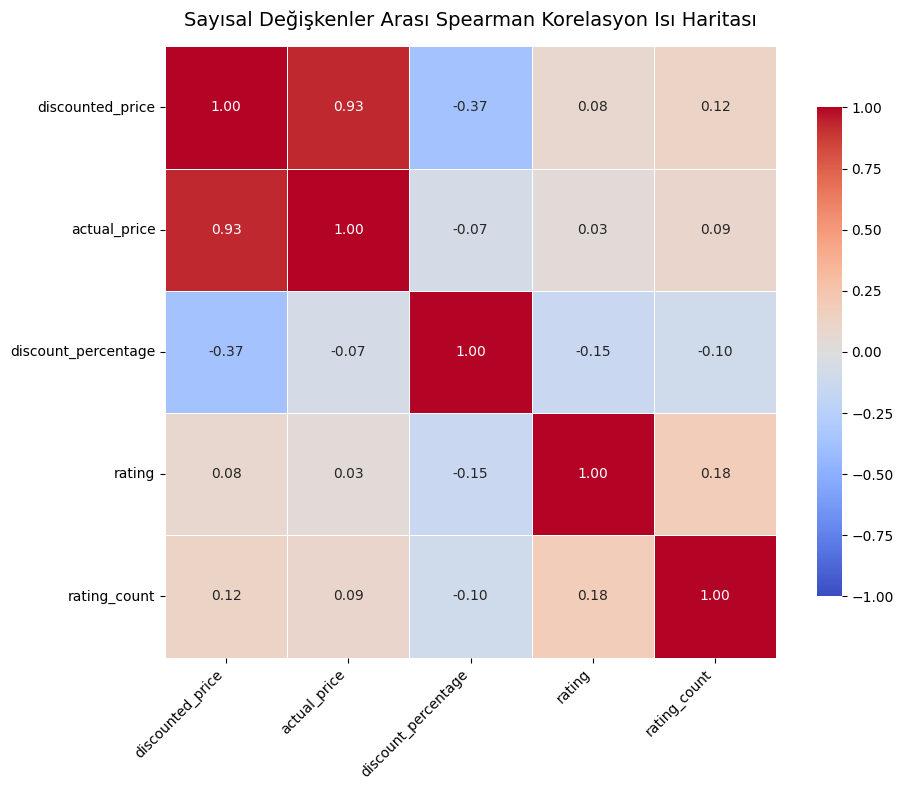

In [48]:
# 1. Korelasyon ve p-değerlerini hesaplayalım (Önceki fonksiyon ile)
sayisal_df = df.select_dtypes(include=[np.number])
katsayi_matrisi, p_val_matrisi = korelasyon_p_matrisi(
    sayisal_df, yontem="spearman"
)

# 2. Grafik Alanını Oluşturma
plt.figure(figsize=(10, 8))

# 3. Üst Üçgen Maskesi (Kendisiyle ve mükerrer eşleşmeleri gizlemek için optional)
mask = np.triu(np.ones_like(katsayi_matrisi, dtype=bool))

# 4. Korelasyon Heatmap'i
sns.heatmap(
    katsayi_matrisi,
    annot=True,  # Değerleri hücre içinde göster
    fmt=".2f",  # Virgülden sonra 2 basamak
    cmap="coolwarm",  # Renk paleti (-1 mavi, 0 beyaz, +1 kırmızı)
    vmin=-1,
    vmax=1,  # Renk skalasının sınırları
    center=0,
    square=True,  # Hücreleri kare yap
    linewidths=0.5,  # Hücreler arası çizgi kalınlığı
    cbar_kws={"shrink": 0.8},  # Renk çubuğu boyutu
)

plt.title(
    "Sayısal Değişkenler Arası Spearman Korelasyon Isı Haritası",
    fontsize=14,
    pad=15,
)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

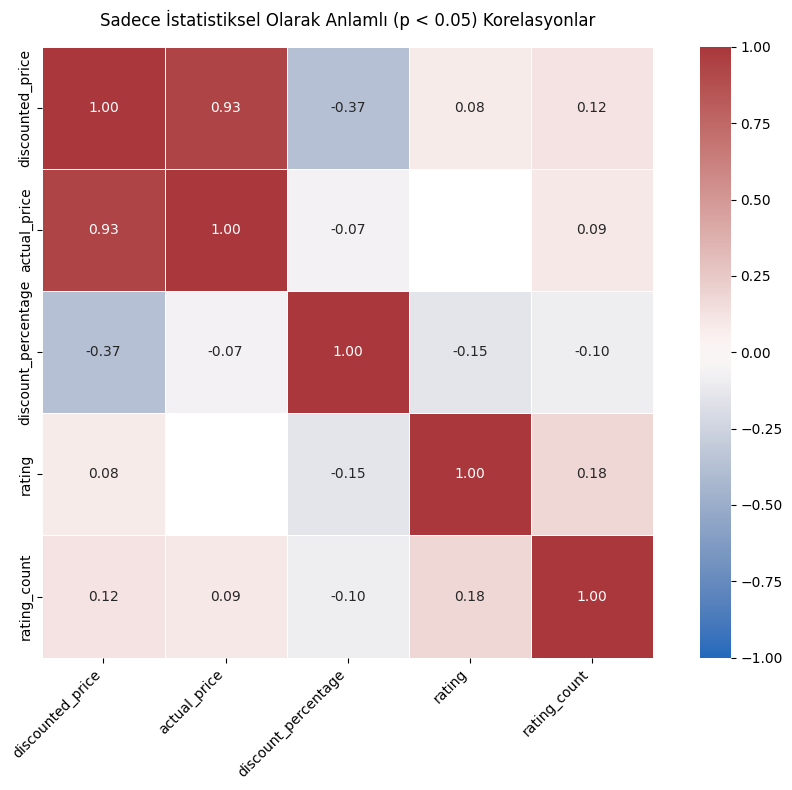

In [49]:
plt.figure(figsize=(10, 8))

# Sadece p < 0.05 olanları göster, anlamlı olmayanları maskele
anlamli_degil_maske = p_val_matrisi >= 0.05

sns.heatmap(
    katsayi_matrisi,
    annot=True,
    fmt=".2f",
    cmap="vlag",
    vmin=-1,
    vmax=1,
    center=0,
    mask=anlamli_degil_maske,  # Anlamlı olmayan kısımlar boş/beyaz kalır
    square=True,
    linewidths=0.5,
)

plt.title("Sadece İstatistiksel Olarak Anlamlı (p < 0.05) Korelasyonlar", pad=15)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

#**Yorum**
- İndirimli fiyat ile asıl fiyat arasında doğal olarak yüksek ve pozitif bir korelasyon görüyoruz. Bunun üzerine yapılabilecek fazla bir yorum yok. Çoklu doğrusal bağlantı (Multicollinearity) riski taşıdığı için bir makine öğrenmesi modelinde veya regresyon analizinde bu veri setini kullanacak olursak İndirimli ve Asıl fiyattan birini veri setinden dışlamamız gerekecektir.
- İndirimli fiyat ile indirim oranı arasında ise zayıf ve negatif yönlü bir korelasyon görüyoruz. Bu durum firmanın düşük fiyatlı ürünlere daha yüksek oranlı indirim yaparak bir satış stratejisi geliştirdiğini göstermektedir.
- İndirim oranı ile rating arasında çok zayıf da olsa bir negatif korelasyon görüyoruz. Bu durum bize müşterilerin psikolojisi ile ilgili birtakım fikirler veriyor. Bu korelasyondan müşterinin yüksek indirimli bir ürün gördüğünde ürüne "elde kalmışlık" şüpheyle yaklaştığı ve daha eleştirel davranığı çıkarılabilir.
- Rating - Rating Sayısı zayıf da olsa bir pozitif korelasyon göstermektedir. Buna birçok sebep verilebilir. Yüksek puanlı ürünlerin daha çok satın alınması ve satın alım sayısının rating sayısını arttırması, düşük puanlı ürünlerin ise yavaş yavaş terk edilmesi iyi birer sebeptir. Ürün popülasyonunun çokluğu ise bu korelasyonu çok kuvvetli olmaktan alıkoyuyor ancak bu zayıf korelasyon bile satışların yapıldığı ülkeyi - ki burada Hindistan - tanımamızı sağlıyor.
- Asıl fiyat ile rating arasında anlamlı bir korelasyon bulunamamıştır (p$ \ge $0.05)